# RAGの性能評価結果の可視化

## ライブラリのインポート

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
from IPython.display import Image as IPImage, display
import pandas as pd
import re

# プロジェクトパスを追加
current_dir = Path.cwd()
print(f"📁 現在のディレクトリ: {current_dir}")

# notebooks/ から プロジェクトルート へ
project_root = current_dir.parent
python_path = project_root / 'python'

print(f"📂 プロジェクトルート: {project_root}")
print(f"🐍 Pythonパス: {python_path}")

# パスを先頭に追加
sys.path.insert(0, str(python_path))

# モジュールインポート
try:
    from visualize.visualize import VisualizationGenerator
    print("✅ モジュールインポート成功")
except ImportError as e:
    print(f"❌ インポートエラー: {e}")
    print("パスを確認してください")

📁 現在のディレクトリ: /mnt/data-sda1/play-ground/g_hayate/25_isco4_dev/notebooks
📂 プロジェクトルート: /mnt/data-sda1/play-ground/g_hayate/25_isco4_dev
🐍 Pythonパス: /mnt/data-sda1/play-ground/g_hayate/25_isco4_dev/python
✅ モジュールインポート成功


In [2]:
SUMMARY_FILE = project_root / "outputs" / "summary.xlsx"
GEMINI_RESULTS_DIR = project_root / "outputs" / "external" / "gemini"
OLLAMA_RESULTS_DIR = project_root / "outputs" / "external" / "ollama"
PLOT_DIR = project_root / "outputs" / "plots"

## 1. データ読み込みと基本統計

In [3]:
summary_df = pd.read_excel(SUMMARY_FILE)
summary_df

,llm,embedding_model,eval_n,hardware,llm.total_execution_time,rag.total_execution_time,llm.avg_response_relevancy,rag.avg_context_precision,rag.avg_context_recall,rag.avg_context_entities_recall,rag.avg_noise_sensitivity,rag.avg_response_relevancy,rag.avg_faithfulness
0,gemini-2.5-flash-lite,embeddinggemma:latest,10,CUDA | NVIDIA RTX 6000 Ada Generation (47GB) |...,00:00,00:00,0.410193,1.0,1,0.358333,0.155952,0.782795,0.968333
1,gemini-2.5-flash,embeddinggemma:latest,10,CUDA | NVIDIA RTX 6000 Ada Generation (47GB) |...,00:01,00:00,0.480375,1.0,1,0.433333,0.078992,0.795522,0.969118
2,gemini-2.5-pro,embeddinggemma:latest,10,CUDA | NVIDIA RTX 6000 Ada Generation (47GB) |...,00:03,00:01,0.419788,1.0,1,0.358333,0.093333,0.799657,0.926667
3,gemini-3-flash-preview,embeddinggemma:latest,10,CUDA | NVIDIA RTX 6000 Ada Generation (47GB) |...,00:01,00:00,0.494082,1.0,1,0.358333,0.231373,0.801155,0.882540
4,gemma3:12b,embeddinggemma:latest,10,CUDA | NVIDIA RTX 6000 Ada Generation (47GB) |...,00:01,00:00,0.691797,1.0,1,0.433333,0.100000,0.791100,0.821667
5,gemma3:1b,embeddinggemma:latest,10,CUDA | NVIDIA RTX 6000 Ada Generation (47GB) |...,00:00,00:00,0.259341,1.0,1,0.408333,0.247619,0.806591,0.782440
6,gemma3:4b,embeddinggemma:latest,10,CUDA | NVIDIA RTX 6000 Ada Generation (47GB) |...,00:00,00:00,0.635734,1.0,1,0.383333,0.136369,0.702864,0.834167
7,gemma3:27b,embeddinggemma:latest,10,CUDA | NVIDIA RTX 6000 Ada Generation (47GB) |...,00:02,00:00,0.615367,1.0,1,0.383333,0.191667,0.798325,0.993333
8,gpt-oss:120b,embeddinggemma:latest,10,CUDA | NVIDIA RTX 6000 Ada Generation (47GB) |...,00:16,00:04,0.744987,1.0,1,0.433333,0.187308,0.788938,0.702619
9,gemini-3-pro-preview,embeddinggemma:latest,10,CUDA | NVIDIA RTX 6000 Ada Generation (47GB) |...,00:04,00:05,0.295531,1.0,1,0.433333,0.132500,0.764998,0.962500


In [4]:
for file_path in GEMINI_RESULTS_DIR.glob("results_*.xlsx"):
    result_df = pd.read_excel(file_path)
    result_df['rag.negative_noise_sensitivity'] = result_df['rag.noise_sensitivity'].map(lambda x: -x)
    model_name = file_path.stem.removeprefix("results_")
    print(f"📊 {model_name}を使用したRAGの評価結果の統計:")
    print(result_df.describe())
    print()
    print(f"📊 {model_name}の良例5件:")
    for i, values in enumerate(result_df.nlargest(5, ['rag.negative_noise_sensitivity', 'rag.response_relevancy', 'rag.faithfulness']).values):
        print(f"=== 良例 {i+1} ===")
        print(f"質問: {values[0]}")
        print(f"回答: {values[5]}")
        print()
    print()
    print(f"📊 {model_name}の悪例5件:")
    for i, values in enumerate(result_df.nsmallest(5, ['rag.negative_noise_sensitivity', 'rag.response_relevancy', 'rag.faithfulness']).values):
        print(f"=== 悪例 {i+1} ===")
        print(f"質問: {values[0]}")
        print(f"回答: {values[5]}")
        print()
    print()

for file_path in OLLAMA_RESULTS_DIR.glob("results_*.xlsx"):
    result_df = pd.read_excel(file_path)
    result_df['rag.negative_noise_sensitivity'] = result_df['rag.noise_sensitivity'].map(lambda x: -x)
    model_name = file_path.stem.removeprefix("results_")
    print(f"📊 {model_name}を使用したRAGの評価結果の統計:")
    print(result_df.describe())
    print()
    print(f"📊 {model_name}の良例5件:")
    for i, values in enumerate(result_df.nlargest(5, ['rag.negative_noise_sensitivity', 'rag.response_relevancy', 'rag.faithfulness']).values):
        print(f"=== 良例 {i+1} ===")
        print(f"質問: {values[0]}")
        print(f"回答: {values[5]}")
        print()
    print()
    print(f"📊 {model_name}の悪例5件:")
    for i, values in enumerate(result_df.nsmallest(5, ['rag.negative_noise_sensitivity', 'rag.response_relevancy', 'rag.faithfulness']).values):
        print(f"=== 悪例 {i+1} ===")
        print(f"質問: {values[0]}")
        print(f"回答: {values[5]}")
        print()
    print()

📊 gemini-2.5-flashを使用したRAGの評価結果の統計:
       llm.execution_time  rag.execution_time  llm.response_relevancy  \
count           10.000000           10.000000               10.000000   
mean            10.273048            2.443911                0.480375   
std              1.864955            1.192133                0.421423   
min              8.264615            1.481296                0.000000   
25%              8.799821            1.715603                0.000000   
50%              9.841190            2.000749                0.676588   
75%             11.274489            2.798888                0.836643   
max             13.467421            5.466405                0.920398   

       rag.context_precision  rag.context_recall  rag.context_entities_recall  \
count                   10.0                10.0                    10.000000   
mean                     1.0                 1.0                     0.433333   
std                      0.0                 0.0               

## 2. 統計可視化

=== 可視化スクリプト ===

1. データの読み込み
   - summary.xlsx: 11件のモデル
   - results_*.xlsx: 11ファイル
     - gemini-2.5-flash: 10件
     - gemini-3-flash-preview: 10件
     - gemini-3-pro-preview: 10件
     - gemini-2.5-flash-lite: 10件
     - gemini-2.5-pro: 10件
     - gemma3:4b: 10件
     - gemma3:1b: 10件
     - gpt-oss:20b: 10件
     - gpt-oss:120b: 10件
     - gemma3:12b: 10件
     - gemma3:27b: 10件

2. グラフの生成
   - execution_time_comparison.png
   - noise_sensitivity_model_comparison.png


/mnt/data-sda1/play-ground/g_hayate/25_isco4_dev/python/visualize/visualize.py:180: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(models, rotation=45, ha="right")


   - response_relevancy_comparison.png
   - faithfulness_model_comparison.png


/mnt/data-sda1/play-ground/g_hayate/25_isco4_dev/python/visualize/visualize.py:180: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(models, rotation=45, ha="right")


   - execution_time_boxplot.png
   - noise_sensitivity_boxplot.png
   - response_relevancy_boxplot.png
   - faithfulness_boxplot.png

=== 完了: /mnt/data-sda1/play-ground/g_hayate/25_isco4_dev/outputs/plots に保存しました ===

📊 生成されたプロット:


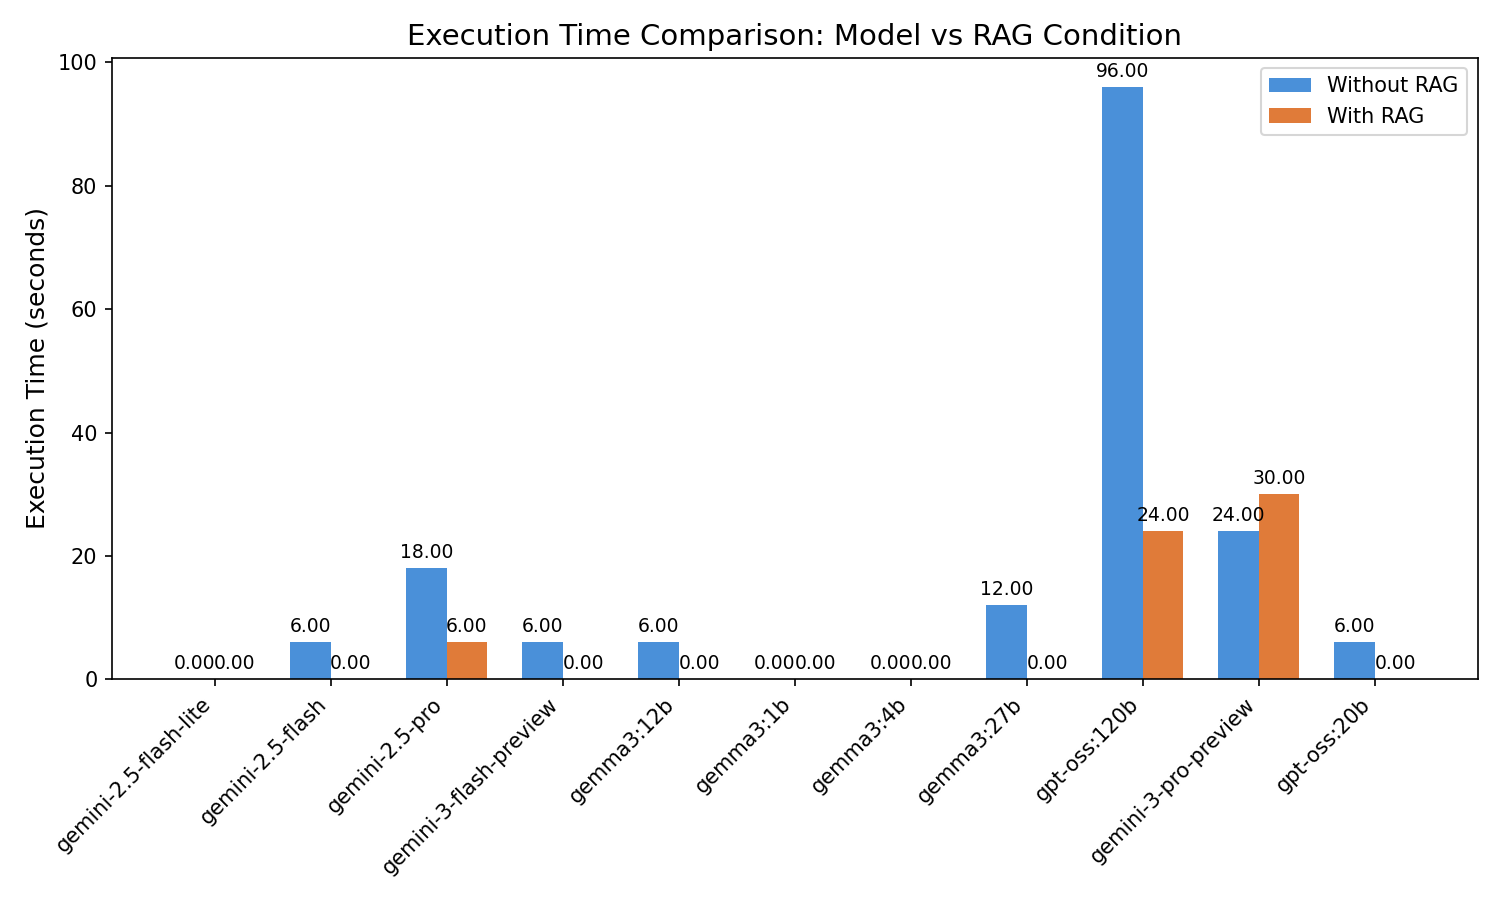

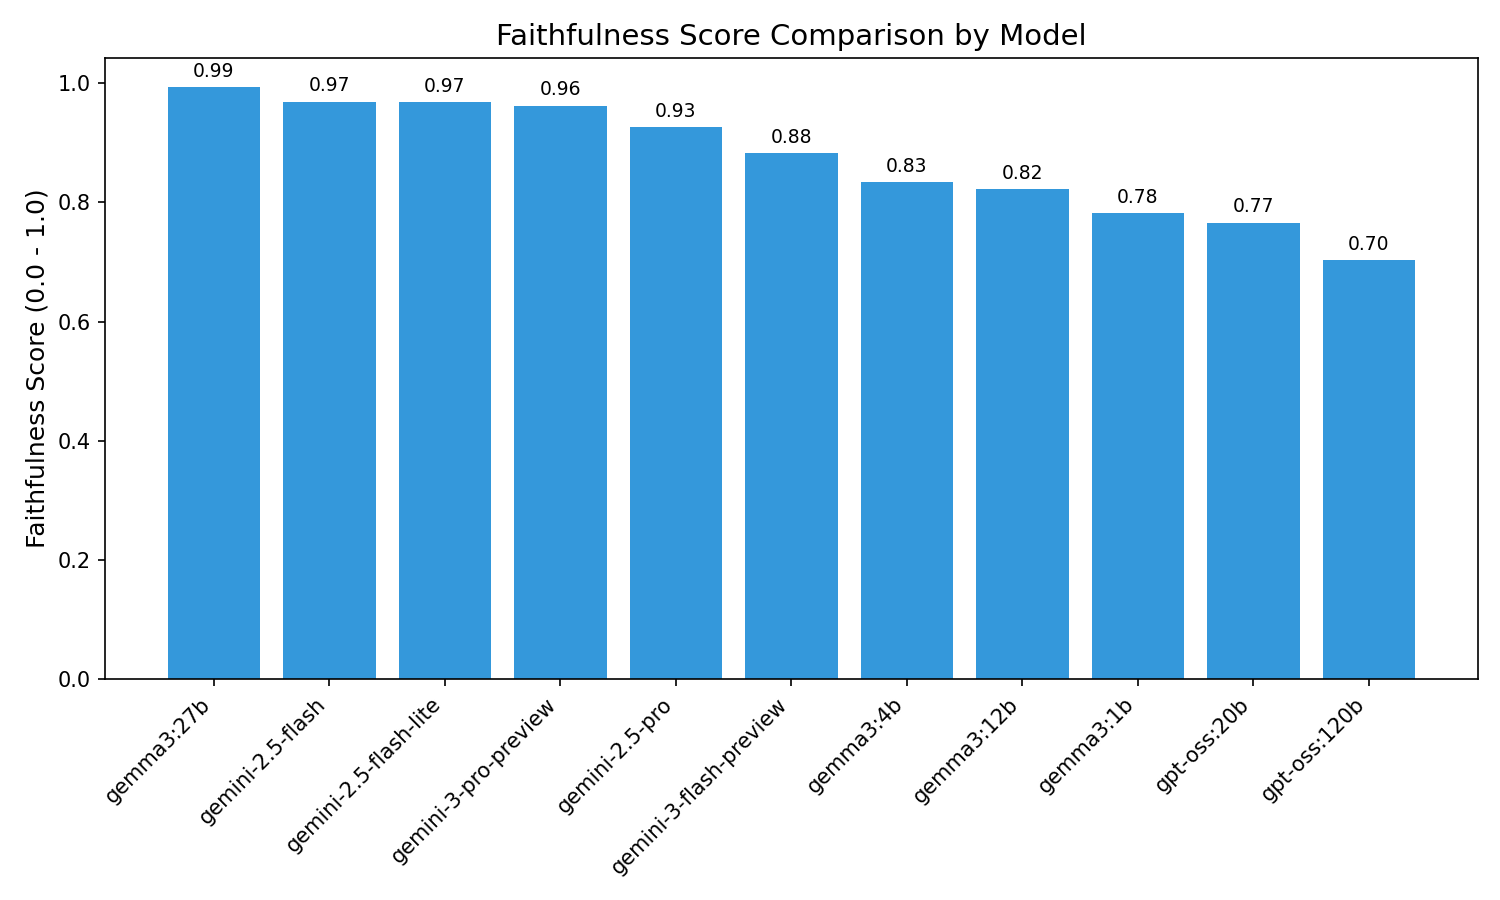

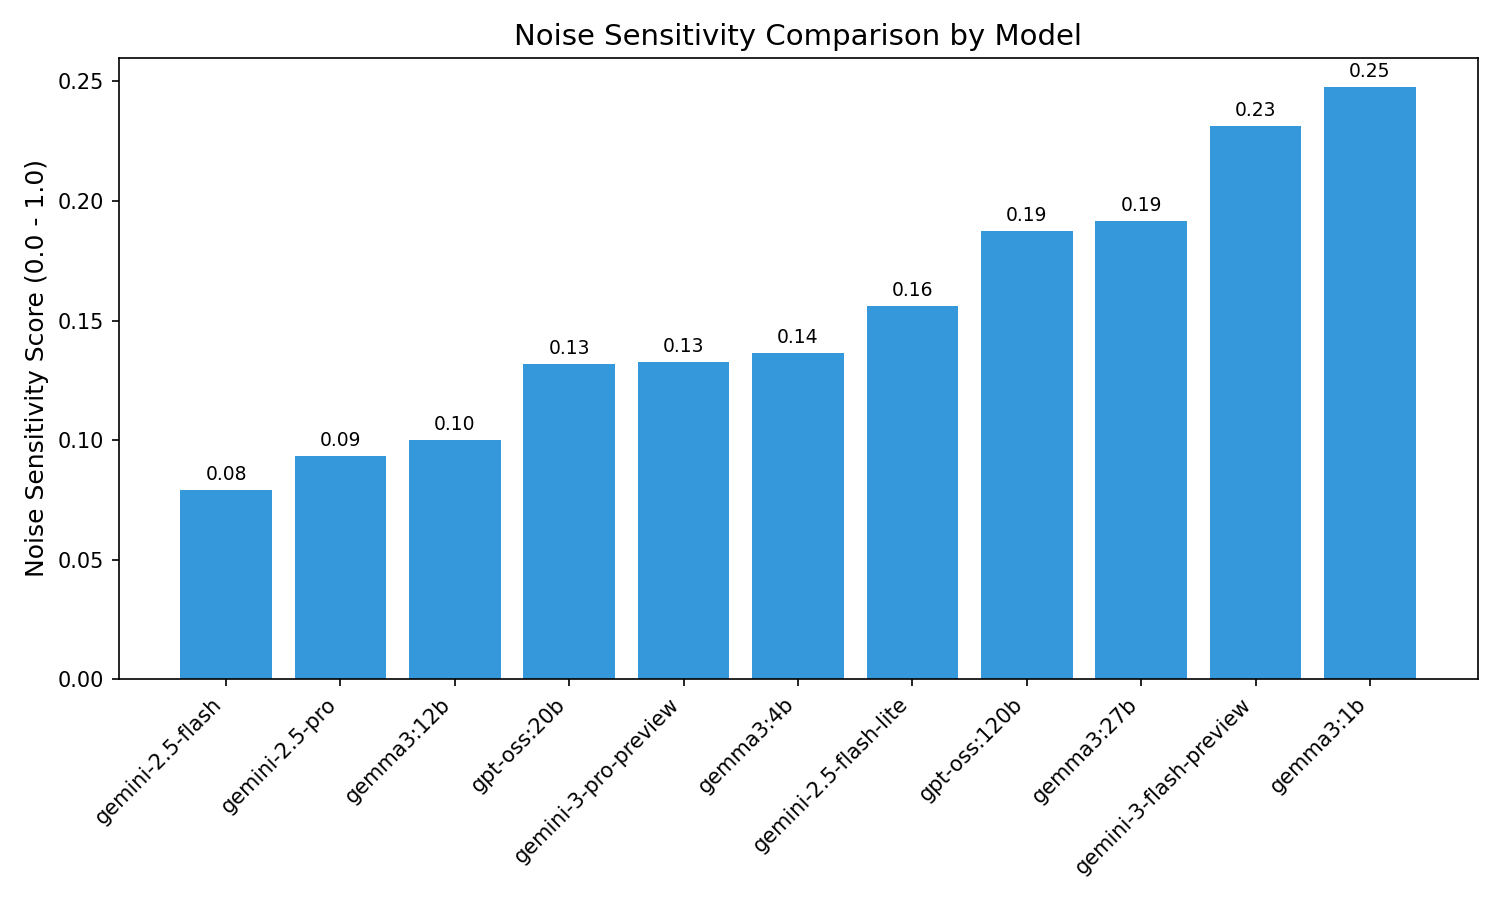

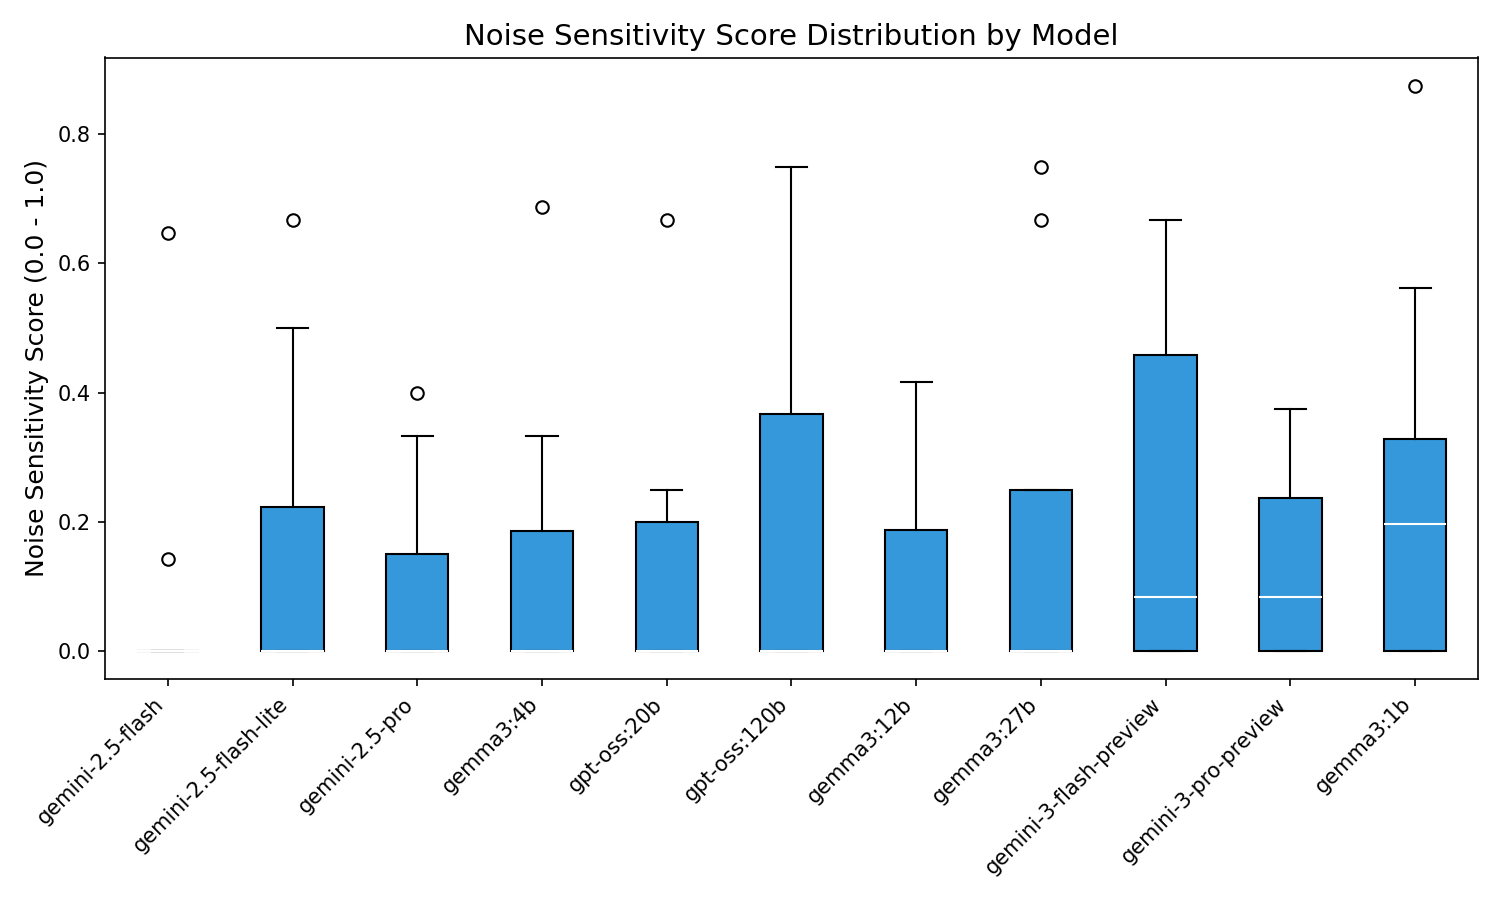

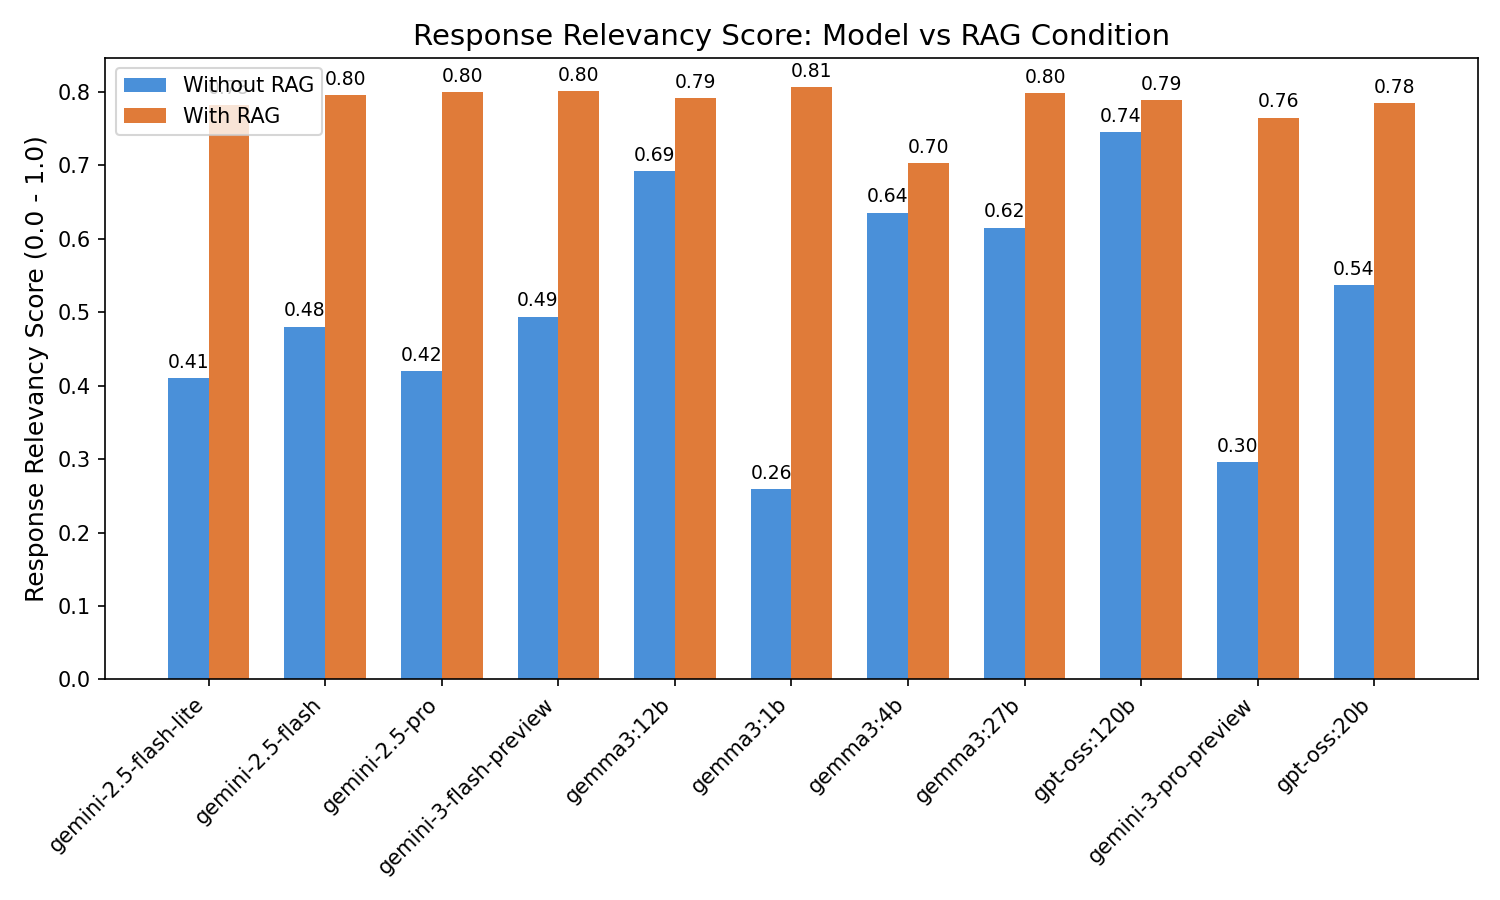

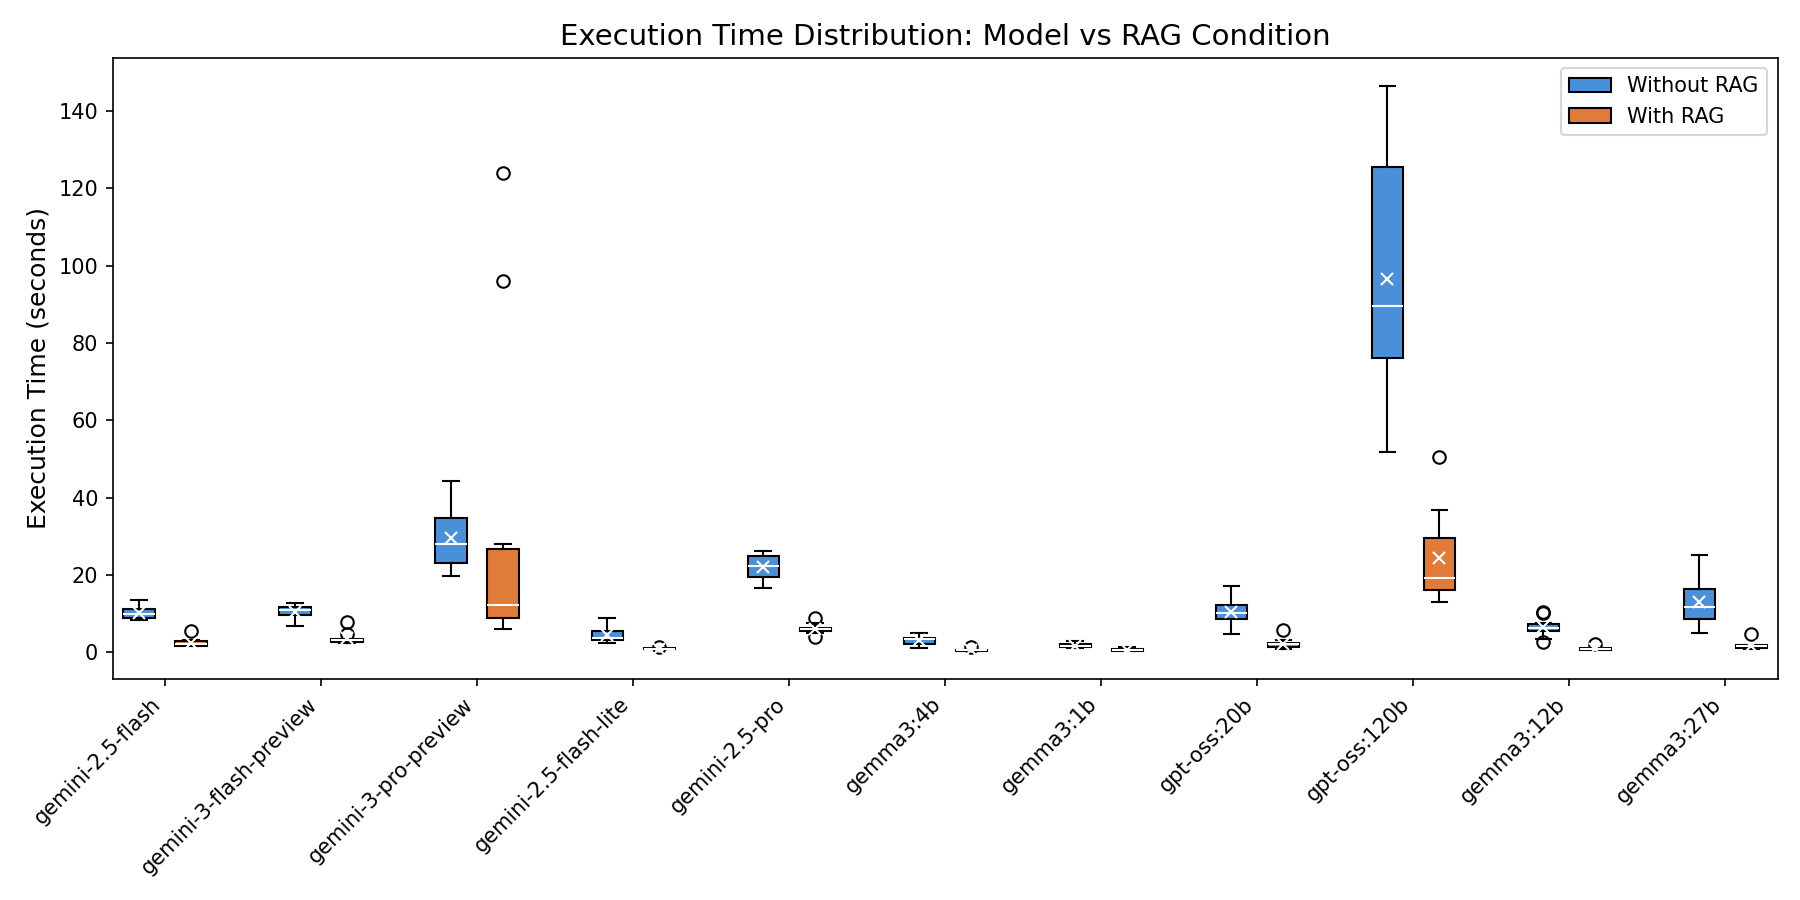

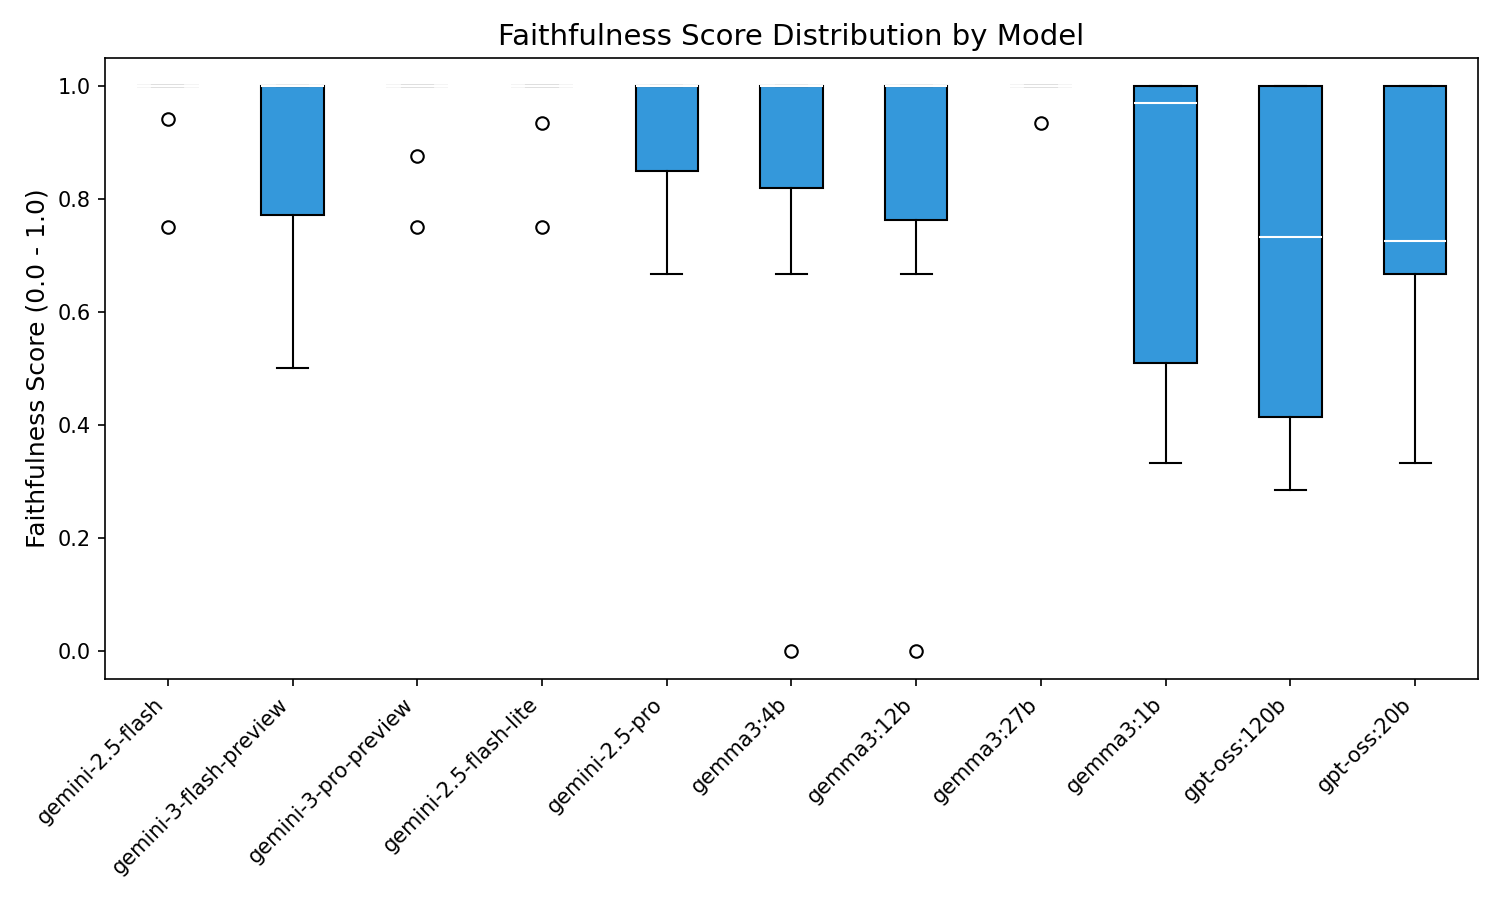

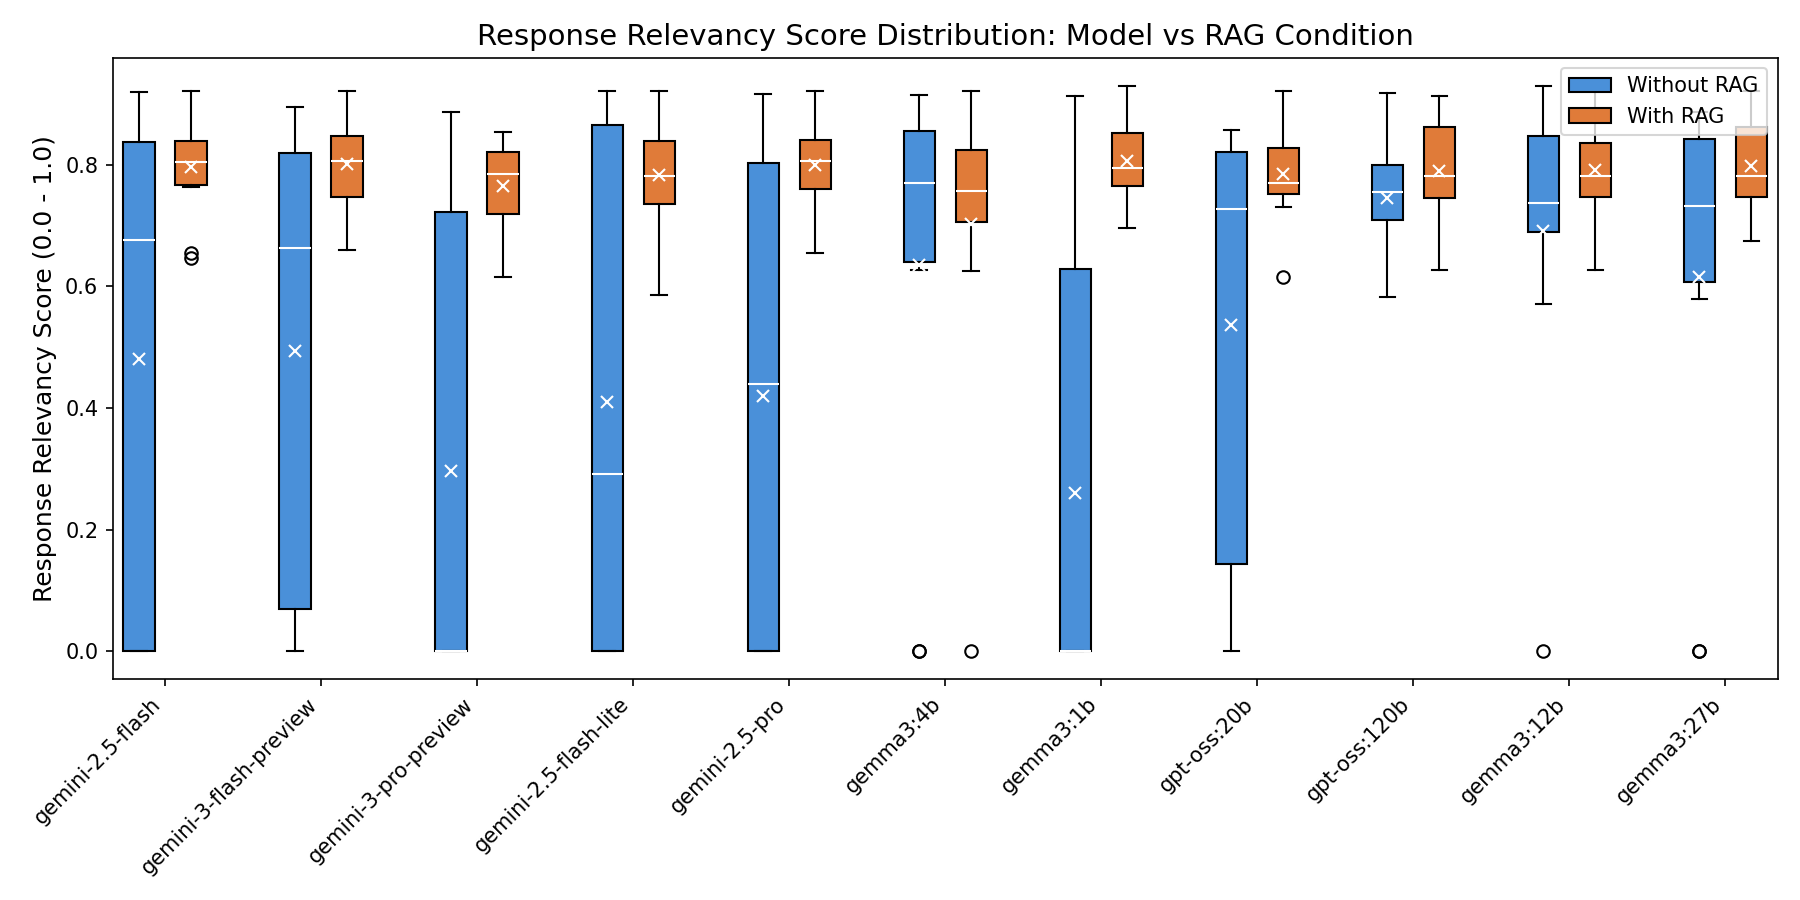

In [5]:
# 📊 統計プロット生成
generator = VisualizationGenerator()
generator.generate_all_visualizations()

# 📈 生成されたプロットを表示
print("\n📊 生成されたプロット:")
for plot_path in PLOT_DIR.glob("*.png"):
    display(IPImage(str(plot_path)))